In [121]:
%pip install --quiet --upgrade kagglehub

Note: you may need to restart the kernel to use updated packages.


In [122]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("ammaraahmad/immigration-to-canada")
filename = "canadian_immegration_data.csv"
filepath = os.path.join(path, filename)

print("Path to dataset files:", path)


Path to dataset files: C:\Users\gg\.cache\kagglehub\datasets\ammaraahmad\immigration-to-canada\versions\1


In [251]:
import pandas as pd

df = pd.read_csv(filepath)
display(df.head())
print("Dataset shape:", df.shape)

categorical_cols = df.select_dtypes(include=["object", "category"]).columns
non_cat_cols = df.columns.difference(categorical_cols)
year_cols = [c for c in non_cat_cols if c.isdigit()]

,Country,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
0,Afghanistan,Asia,Southern Asia,Developing regions,16,39,39,47,71,340,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
1,Albania,Europe,Southern Europe,Developed regions,1,0,0,0,0,0,...,1223,856,702,560,716,561,539,620,603,15699
2,Algeria,Africa,Northern Africa,Developing regions,80,67,71,69,63,44,...,3626,4807,3623,4005,5393,4752,4325,3774,4331,69439
3,American Samoa,Oceania,Polynesia,Developing regions,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,6
4,Andorra,Europe,Southern Europe,Developed regions,0,0,0,0,0,0,...,0,1,1,0,0,0,0,1,1,15


Dataset shape: (195, 39)


In [140]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

## Missing values and outliers

In [143]:
# Missing values summary
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean()*100).sort_values(ascending=False)
missing_df = pd.concat([missing, missing_percent], axis=1, keys=['missing_count','missing_percent'])

# Quick missingness heatmap for columns with any missing values
cols_with_na = missing[missing>0].index.tolist()
if cols_with_na:
    display(missing_df[missing_df.missing_count>0])
    plt.figure(figsize=(10, min(6, len(cols_with_na)*0.3+1)))
    sns.heatmap(df[cols_with_na].isnull(), cbar=False)
    plt.title('Missing values heatmap')
    plt.show()
else:
    print('No missing values detected')

# Outlier detection
outlier_summary = []
for c in non_cat_cols:
    col = df[c].dropna()
    if col.empty:
        continue
    q1, q3 = np.percentile(col, [25,75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    iqr_outliers = ((col < lower) | (col > upper)).sum()
    outlier_summary.append({'column': c, 'iqr_outliers': int(iqr_outliers)})

outlier_df = pd.DataFrame(outlier_summary).sort_values('iqr_outliers', ascending=False)
display(outlier_df.T)

No missing values detected


,0,19,15,2,1,34,3,20,33,16,...,21,24,32,29,7,10,11,13,26,28
column,1980,1999,1995,1982,1981,Total,1983,2000,2013,1996,...,2001,2004,2012,2009,1987,1990,1991,1993,2006,2008
iqr_outliers,31,31,31,30,30,30,30,29,29,29,...,25,25,25,25,24,24,24,24,24,24


## Distributions

In [283]:
display(df[categorical_cols].describe().T)
describer = df.set_index("Country")[year_cols].T.describe().T
describer

,count,unique,top,freq
Country,195,195,Afghanistan,1
Continent,195,6,Africa,54
Region,195,22,Western Asia,18
DevName,195,2,Developing regions,147


,count,mean,std,min,25%,50%,75%,max
Country,,,,,,,,
Afghanistan,34.0,1724.676471,1196.705040,16.0,762.75,1752.0,2615.00,4067.0
Albania,34.0,461.735294,534.982997,0.0,2.25,210.0,712.50,1816.0
Algeria,34.0,2042.323529,1771.709374,44.0,290.00,1948.0,3621.25,5393.0
American Samoa,34.0,0.176471,0.458627,0.0,0.00,0.0,0.00,2.0
Andorra,34.0,0.441176,0.785905,0.0,0.00,0.0,1.00,3.0
...,...,...,...,...,...,...,...,...
Viet Nam,34.0,2857.235294,1674.097424,1191.0,1760.00,2139.5,3341.25,7583.0
Western Sahara,34.0,0.058824,0.238833,0.0,0.00,0.0,0.00,1.0
Yemen,34.0,87.794118,71.695391,0.0,13.50,117.0,140.75,217.0


## Dataset inspection

In [144]:
def compress_years(years):
    years = sorted(years)
    ranges = []
    start = prev = years[0]

    for y in years[1:]:
        if y == prev + 1:
            prev = y
        else:
            ranges.append(f"{start}-{prev}" if start != prev else str(start))
            start = prev = y

    ranges.append(f"{start}-{prev}" if start != prev else str(start))
    return ", ".join(ranges)

In [146]:
top_countries = {}

for c in year_cols:
    year = int(c)
    max_country = df.loc[df[c].idxmax(), "Country"]
    max_immigrants = df[c].max()

    entry = top_countries.setdefault(max_country, {
        "Top immigrants by year": max_immigrants,
        "Top year": year,
        "Years": []
    })

    entry["Years"].append(year)

    if max_immigrants > entry["Top immigrants by year"]:
        entry["Top immigrants by year"] = max_immigrants
        entry["Top year"] = year

top_countries_df = (
    pd.DataFrame(top_countries).T
    .sort_values("Top immigrants by year", ascending=False)
)

top_countries_df["Years"] = top_countries_df["Years"].apply(compress_years)

display(top_countries_df)

,Top immigrants by year,Top year,Years
China,42584,2005,"1998-2005, 2008-2009, 2013"
United Kingdom of Great Britain and Northern Ireland,39231,1994,1980-1997
Philippines,38617,2010,2010-2012
India,33848,2006,2006-2007


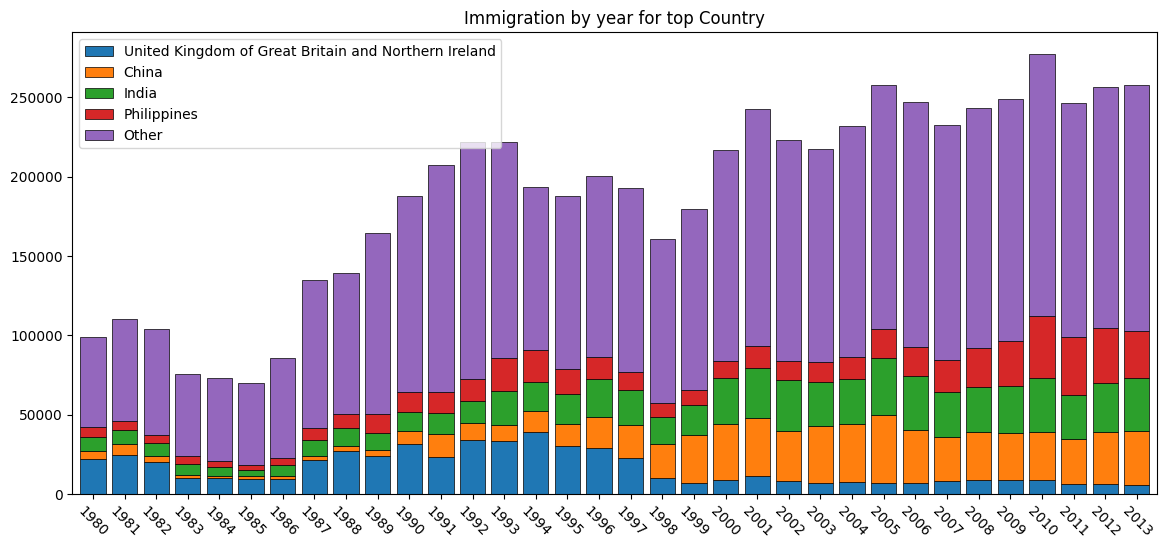

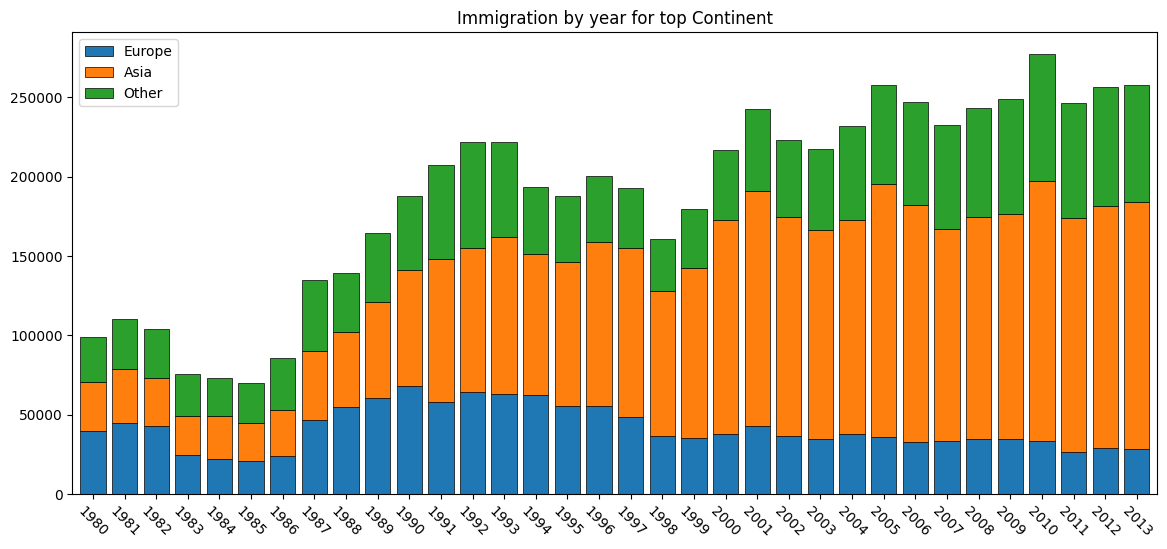

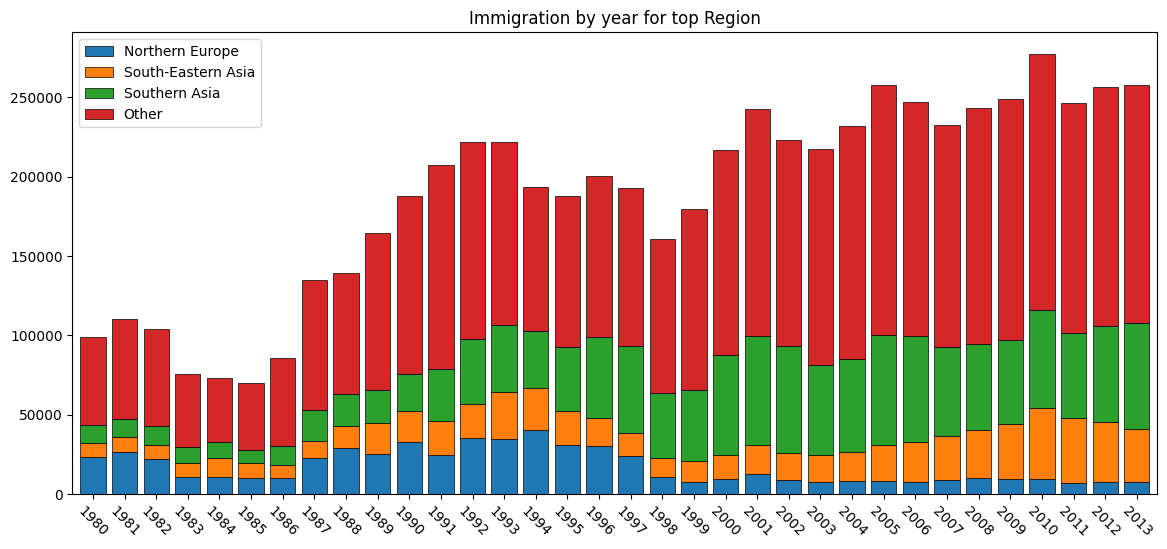

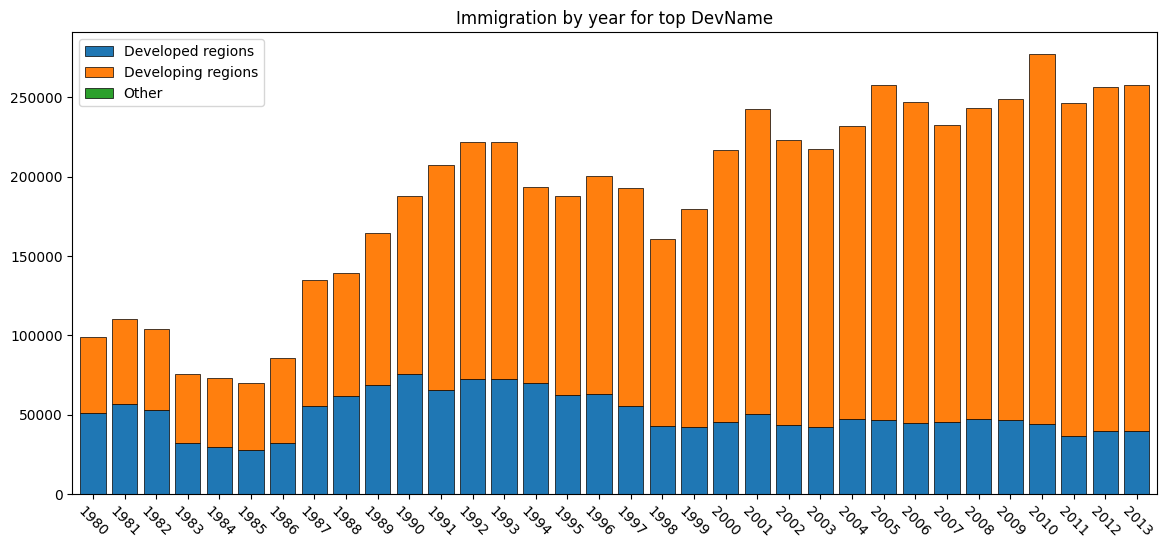

In [250]:
for c in categorical_cols:
    grouped_by_df = df.groupby(c)[year_cols].sum()
    top = grouped_by_df.idxmax(axis=0).unique()

    fig, ax = plt.subplots()
    fig.set_size_inches(14, 6)

    top = grouped_by_df.loc[top][year_cols].T
    other = grouped_by_df.drop(index=top).sum()[year_cols].T
    top_other_df = pd.concat([top, other.rename("Other")], axis=1)
    
    top_other_df.plot(
        ax=ax,
        kind="bar",
        stacked=True,
        edgecolor="black",
        width=0.8,
        linewidth=0.5,
    )

    # categories = top_other_df.columns.unique()
    # palette = dict(zip(categories, sns.color_palette("tab10", len(categories))))

    # for year, y_row in top_other_df.iterrows():
    #     for i, (name, row) in enumerate(y_row.sort_values(ascending=False).items()):
    #         ax.bar(
    #             year,
    #             row,
    #             # width=0.8 - 0.2 * i,
    #             color=palette[name]
    #         )


    ax.set_xticks(range(len(year_cols)))
    ax.set_xticklabels(year_cols, rotation=-45)
    ax.set_title(f"Immigration by year for top {c}")
    ax.legend(loc='upper left')
    plt.show()

## Relationships and correlations